In [2]:
import pandas as pd
import os
import statsmodels.formula.api as smf

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Section1. regressions with stress_qa and car (0,1) with controls

In [32]:
master_final = pd.read_csv('../Data/master_final.csv')

In [105]:
master_final.shape

(8036, 20)

In [11]:
master_final['call_date'].max()

'2024-12-19'

### stress_qa and car (0,1)

In [17]:
master_final.columns

Index(['symbol', 'year', 'quarter', 'call_date', 'stress_pr', 'stress_qa',
       'stress_whole', 'car_01', 'car_0180', 'vol', 'mom', 'POSWORDS',
       'NEGWORDS', 'lnmve', 'bm', 'atq', 'UE', 'actual_eps', 'median_forecast',
       'numest'],
      dtype='str')

In [27]:
df_1 = master_final[['car_01', 'stress_qa', 'vol', 'mom', 'POSWORDS', 'NEGWORDS', 'lnmve', 'bm', 'atq', 'UE', 'median_forecast']].dropna()
model1 = smf.ols(formula='car_01 ~ stress_qa + vol + mom + POSWORDS + NEGWORDS + lnmve + bm + atq + UE + median_forecast', data=df_1).fit()

In [28]:
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 car_01   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     24.87
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           6.61e-47
Time:                        10:29:44   Log-Likelihood:                 10311.
No. Observations:                7507   AIC:                        -2.060e+04
Df Residuals:                    7496   BIC:                        -2.052e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0551      0.010      5.675      0.000       0.036       0.074
stress_qa          -0.0110      0.001    -10.039      0.000      -0.013      -0.009
vol                 0.3586      0.075      4.753      0.000       0.211       0.506
mom                -0.0017      0.004     -0.461      0.645      -0.009       0.005
POSWORDS            0.0652      0.115      0.569      0.569      -0.159       0.290
NEGWORDS           -0.7016      0.215     -3.267      0.001      -1.123      -0.281
lnmve              -0.0028      0.001     -3.543      0.000      -0.004      -0.001
bm                 -0.0044      0.003     -1.720      0.086      -0.009       0.001
atq              4.466e-09   2.86e-09      1.561      0.119   -1.14e-09    1.01e-08
UE                  0.0126      0.001      8.829      0.000       0.010       0.015
median_forecast    -0.0009      0.000     -1.949      0.051      -0.002    4.87e-06
==============================================================================
Omnibus:                      575.645   Durbin-Watson:                   1.958
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3195.952
Skew:                          -0.089   Prob(JB):                         0.00
Kurtosis:                       6.192   Cond. No.                     9.24e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.24e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### with HC3 robust standard errors

In [23]:
df_2 = master_final[['car_01', 'stress_qa', 'vol', 'mom', 'POSWORDS', 'NEGWORDS', 'lnmve', 'bm', 'atq', 'UE']].dropna()
model2 = smf.ols(formula='car_01 ~ stress_qa + vol + mom + POSWORDS + NEGWORDS + lnmve + bm + atq + UE', data=df_1).fit(cov_type='HC3')
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 car_01   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     19.30
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           4.93e-29
Time:                        10:09:11   Log-Likelihood:                 10309.
No. Observations:                7507   AIC:                        -2.060e+04
Df Residuals:                    7497   BIC:                        -2.053e+04
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0550      0.010      5.471      0.0

/Users/yiqisun/Documents/Thesis/NLP project/venv/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 8
  warnings.warn('covariance of constraints does not have full '


In [ ]:
results = model2

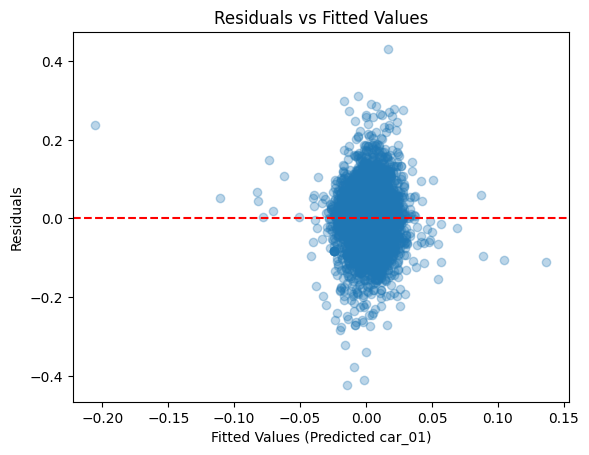

In [38]:
plt.scatter(results.fittedvalues, results.resid, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values (Predicted car_01)')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

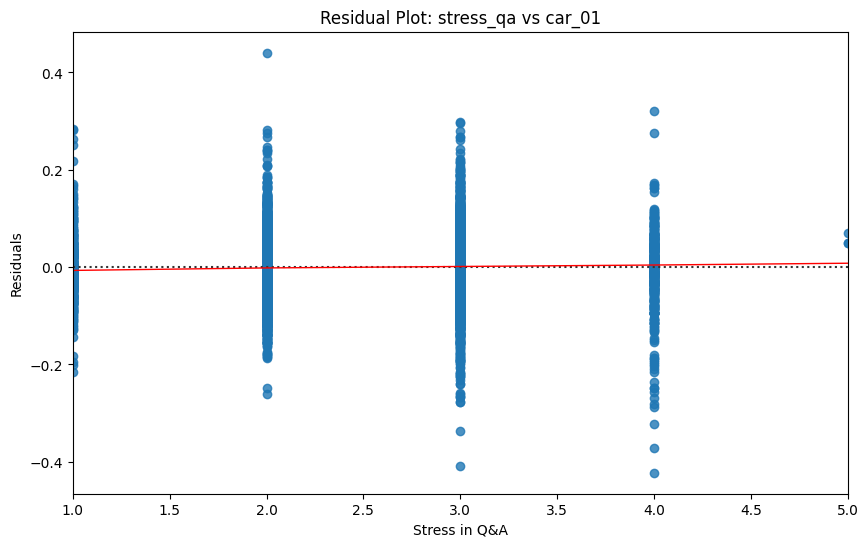

In [35]:
# Assuming 'car_01' is your dependent variable and 'stress_qa' is your main independent variable
plt.figure(figsize=(10, 6))
sns.residplot(data=master_final, x='stress_qa', y='car_01', lowess=True, 
              line_kws={'color': 'red', 'lw': 1})

plt.title('Residual Plot: stress_qa vs car_01')
plt.xlabel('Stress in Q&A')
plt.ylabel('Residuals')
plt.show()

### try winsorization for outliers

In [41]:
master_final.columns

Index(['symbol', 'year', 'quarter', 'call_date', 'stress_pr', 'stress_qa',
       'stress_whole', 'car_01', 'car_0180', 'vol', 'mom', 'POSWORDS',
       'NEGWORDS', 'lnmve', 'bm', 'atq', 'UE', 'actual_eps', 'median_forecast',
       'numest'],
      dtype='str')

In [46]:
def winsorize(series, lower=0.01, upper=0.99):
    low  = series.quantile(lower)
    high = series.quantile(upper)
    return series.clip(lower=low, upper=high)

df_winsorization = master_final[['car_01', 'car_0180', 'stress_qa', 'vol', 'mom', 'POSWORDS', 'NEGWORDS', 'lnmve', 'bm', 'atq', 'UE', 'median_forecast']].dropna()
for col in ['car_01', 'car_0180', 'vol', 'mom', 
            'lnmve', 'bm', 'UE', 'POSWORDS', 'NEGWORDS', 'median_forecast']:
    df_winsorization[col] = winsorize(df_winsorization[col])

model4 = smf.ols(formula='car_01 ~ stress_qa + vol + mom + POSWORDS + NEGWORDS + lnmve + bm + atq + UE + median_forecast', data=df_winsorization).fit(cov_type='HC3')
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                 car_01   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     35.18
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           1.77e-61
Time:                        11:22:53   Log-Likelihood:                 10860.
No. Observations:                7507   AIC:                        -2.170e+04
Df Residuals:                    7496   BIC:                        -2.162e+04
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0463      0.010     

/Users/yiqisun/Documents/Thesis/NLP project/venv/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 9
  warnings.warn('covariance of constraints does not have full '


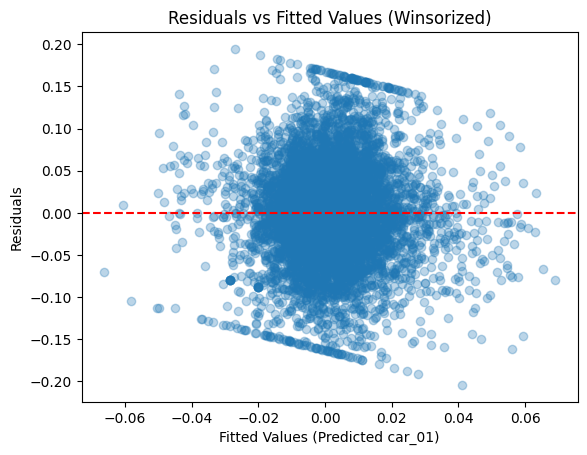

In [45]:
plt.scatter(model4.fittedvalues, model4.resid, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values (Predicted car_01)')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values (Winsorized)')
plt.show()

### check VIF

In [24]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. Define the independent variables from your model
# (Adjust this list if you want to test other columns)
X_cols = ['stress_qa', 'vol', 'mom', 'POSWORDS', 'NEGWORDS', 'lnmve', 'bm']

# 2. Filter the dataframe and drop rows with NaNs (VIF doesn't like them)
X = master_final[X_cols].dropna()

# 3. CRITICAL: Add a constant (intercept) 
# VIF is calculated by regressing each variable against the others
X = add_constant(X)

# 4. Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

     feature         VIF
0      const  166.852112
1  stress_qa    1.080433
2        vol    1.093647
3        mom    1.036369
4   POSWORDS    1.065371
5   NEGWORDS    1.114142
6      lnmve    1.078638
7         bm    1.089459


In [89]:
master_final['stress_pr'].value_counts(dropna=False)
# master_final['stress_qa'].value_counts(dropna=False)

stress_pr
2.0    3736
NaN    2260
3.0     989
1.0     968
4.0      83
Name: count, dtype: int64

### try scaling

In [29]:
# Select your features
features = ['stress_qa', 'vol', 'mom', 'POSWORDS', 'NEGWORDS', 'lnmve', 'bm', 'median_forecast']

# Standardize them
master_data_scaled = master_final.copy()
for col in features:
    master_data_scaled[col] = (master_final[col] - master_final[col].mean()) / master_final[col].std()

# Now run your OLS using master_data_scaled
model3 = smf.ols(formula='car_01 ~ stress_qa + vol + mom + POSWORDS + NEGWORDS + lnmve + bm + median_forecast', data=master_data_scaled).fit(cov_type='HC3')
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                 car_01   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     17.09
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           1.98e-25
Time:                        10:31:05   Log-Likelihood:                 10271.
No. Observations:                7507   AIC:                        -2.052e+04
Df Residuals:                    7498   BIC:                        -2.046e+04
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0013      0.001     

### we look at univariate regression first.

In [ ]:
uni_model_stress_qa = smf.ols(formula='car_01 ~ stress_qa', data=master_final).fit(cov_type='HC3')
print(uni_model_stress_qa.summary())

### run a model with every variable

In [47]:
reg_df = master_final[['car_01', 'stress_qa','stress_pr', 'vol', 'mom', 'POSWORDS', 'NEGWORDS', 'lnmve', 'bm', 'atq', 'UE', 'median_forecast']].dropna()

full_model = smf.ols(formula='car_01 ~ stress_qa + stress_pr + vol + mom + POSWORDS + NEGWORDS + lnmve + bm + atq + UE + median_forecast', data=reg_df).fit(cov_type='HC3')
print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 car_01   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     18.12
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           5.18e-33
Time:                        11:25:30   Log-Likelihood:                 7579.9
No. Observations:                5373   AIC:                        -1.514e+04
Df Residuals:                    5361   BIC:                        -1.506e+04
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0813      0.012     

/Users/yiqisun/Documents/Thesis/NLP project/venv/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 10
  warnings.warn('covariance of constraints does not have full '


### try winsorization

In [48]:
reg_df = master_final[['car_01', 'stress_qa','stress_pr', 'vol', 'mom', 'POSWORDS', 'NEGWORDS', 'lnmve', 'bm', 'atq', 'UE', 'median_forecast']].dropna()
for col in features:
    reg_df[col] = (reg_df[col] - reg_df[col].mean()) / reg_df[col].std()

full_model = smf.ols(formula='car_01 ~ stress_qa + stress_pr + vol + mom + POSWORDS + NEGWORDS + lnmve + bm + atq + UE + median_forecast', data=reg_df).fit(cov_type='HC3')
print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 car_01   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     16.48
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           2.14e-32
Time:                        11:28:19   Log-Likelihood:                 7579.9
No. Observations:                5373   AIC:                        -1.514e+04
Df Residuals:                    5361   BIC:                        -1.506e+04
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0278      0.004     

### try without atq

In [49]:
reg_df_2 = master_final[['car_01', 'stress_qa','stress_pr', 'vol', 'mom', 'POSWORDS', 'NEGWORDS', 'lnmve', 'bm', 'UE', 'median_forecast']].dropna()

full_model_without_atq = smf.ols(formula='car_01 ~ stress_qa + stress_pr + vol + mom + POSWORDS + NEGWORDS + lnmve + bm + UE + median_forecast', data=reg_df_2).fit(cov_type='HC3')
print(full_model_without_atq.summary())

                            OLS Regression Results                            
Dep. Variable:                 car_01   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     17.58
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           6.44e-32
Time:                        11:36:00   Log-Likelihood:                 7575.0
No. Observations:                5373   AIC:                        -1.513e+04
Df Residuals:                    5362   BIC:                        -1.506e+04
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0678      0.011     

### check Full model VIF


In [52]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. List all predictors from your most recent OLS output
full_model_cols = [
    'stress_qa', 'stress_pr', 'vol', 'mom', 
    'POSWORDS', 'NEGWORDS', 'lnmve', 'bm', 'atq', 'UE'
]

# 2. Prepare the data (drop NaNs or VIF will return NaNs)
vif_df = master_final[full_model_cols].dropna()

# 3. Add a constant (Statsmodels VIF requires this to calculate correctly)
X_vif = add_constant(vif_df)

# 4. Calculate VIF for each feature
vif_results = pd.DataFrame()
vif_results["Feature"] = X_vif.columns
vif_results["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print(vif_results.sort_values(by="VIF", ascending=False))

      Feature         VIF
0       const  219.993641
9         atq    1.369088
7       lnmve    1.340045
8          bm    1.317390
2   stress_pr    1.295232
6    NEGWORDS    1.217000
1   stress_qa    1.168037
3         vol    1.156975
5    POSWORDS    1.110098
4         mom    1.072154
10         UE    1.019029


### try without negative words

In [51]:
reg_df_no_neg = master_final[['car_01', 'stress_qa','stress_pr', 'vol', 'mom','lnmve', 'bm', 'UE', 'median_forecast']].dropna()

full_model_without_lm = smf.ols(formula='car_01 ~ stress_qa + stress_pr + vol + mom + lnmve + bm + UE + median_forecast', data=reg_df_no_neg).fit(cov_type='HC3')
print(full_model_without_lm.summary())

                            OLS Regression Results                            
Dep. Variable:                 car_01   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     21.74
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           6.97e-33
Time:                        11:37:21   Log-Likelihood:                 7574.4
No. Observations:                5373   AIC:                        -1.513e+04
Df Residuals:                    5364   BIC:                        -1.507e+04
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0691      0.011     

### try logging the atp

### Placebo test

In [83]:
import numpy as np
import statsmodels.api as sm

# 1. Define your features
features = ['stress_qa', 'stress_pr', 'vol', 'mom', 'POSWORDS', 'NEGWORDS', 'lnmve', 'bm', 'UE']

# 2. CREATE A CLEAN SUBSET FIRST
# This drops any rows that have a NaN in your features or your dependent variable
clean_df = master_final[features + ['car_01']].dropna()

# 3. Check for infinite values (just in case)
clean_df = clean_df.replace([np.inf, -np.inf], np.nan).dropna()

# 4. Generate Placebo Stress using the length of the CLEANED dataframe
placebo_stress = np.random.normal(
    loc=clean_df['stress_pr'].mean(), 
    scale=clean_df['stress_pr'].std(), 
    size=len(clean_df)
)

# 5. Set up X and y from the cleaned data
X_placebo = clean_df[features].copy()
X_placebo['stress_pr'] = placebo_stress
X_placebo = sm.add_constant(X_placebo)
y_placebo = clean_df['car_01']

# 6. Run the regression
placebo_results = sm.OLS(y_placebo, X_placebo).fit(cov_type='HC3')

print("--- Placebo Test Results (Cleaned) ---")
print(placebo_results.summary().tables[1])

--- Placebo Test Results (Cleaned) ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0460      0.012      3.979      0.000       0.023       0.069
stress_qa     -0.0113      0.002     -7.218      0.000      -0.014      -0.008
stress_pr      0.0018      0.001      1.383      0.167      -0.001       0.004
vol            0.3207      0.106      3.030      0.002       0.113       0.528
mom           -0.0044      0.006     -0.680      0.496      -0.017       0.008
POSWORDS       0.0748      0.145      0.516      0.606      -0.209       0.359
NEGWORDS      -0.8026      0.266     -3.014      0.003      -1.325      -0.281
lnmve         -0.0021      0.001     -2.473      0.013      -0.004      -0.000
bm            -0.0005      0.003     -0.175      0.861      -0.006       0.005
UE             0.0145      0.005      2.784      0.005       0.004       0.025


### subsample test

In [84]:
half_1 = master_final.sample(frac=0.5, random_state=1)
half_2 = master_final.drop(half_1.index)

In [85]:
half_1_ols = smf.ols(formula='car_01 ~ stress_qa + stress_pr + vol + mom + POSWORDS + NEGWORDS + lnmve + bm + UE + median_forecast', data=half_1
                     ).fit(cov_type='HC3')
half_1_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 car_01   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     9.416
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           1.58e-15
Time:                        13:03:39   Log-Likelihood:                 3753.5
No. Observations:                2675   AIC:                            -7485.
Df Residuals:                    2664   BIC:                            -7420.
Df Model:                          10                                         
Covariance Type:                  HC3                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0734      0.017      4.247      0.000       0.040       0.107
stress_qa          -0.0087      0.002     -4.090      0.000      -0.013      -0.005
stress_pr          -0.0137      0.002     -5.827      0.000      -0.018      -0.009
vol                 0.3750      0.162      2.317      0.021       0.058       0.692
mom                -0.0099      0.008     -1.209      0.227      -0.026       0.006
POSWORDS            0.0771      0.206      0.374      0.709      -0.327       0.482
NEGWORDS           -0.0403      0.379     -0.106      0.915      -0.783       0.703
lnmve              -0.0027      0.001     -2.045      0.041      -0.005      -0.000
bm                 -0.0033      0.004     -0.764      0.445      -0.012       0.005
UE                  0.0165      0.004      4.373      0.000       0.009       0.024
median_forecast    -0.0013      0.001     -1.704      0.088      -0.003       0.000
==============================================================================
Omnibus:                      198.401   Durbin-Watson:                   2.064
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              889.163
Skew:                          -0.201   Prob(JB):                    8.33e-194
Kurtosis:                       5.796   Cond. No.                     3.86e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 3.86e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [86]:
half_2_ols = smf.ols(formula='car_01 ~ stress_qa + stress_pr + vol + mom + POSWORDS + NEGWORDS + lnmve + bm + UE + median_forecast', data=half_2
                     ).fit(cov_type='HC3')
half_2_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 car_01   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     9.240
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           3.42e-15
Time:                        13:04:25   Log-Likelihood:                 3823.9
No. Observations:                2698   AIC:                            -7626.
Df Residuals:                    2687   BIC:                            -7561.
Df Model:                          10                                         
Covariance Type:                  HC3                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0622      0.015      4.014      0.000       0.032       0.093
stress_qa          -0.0065      0.002     -2.912      0.004      -0.011      -0.002
stress_pr          -0.0151      0.002     -6.342      0.000      -0.020      -0.010
vol                 0.5196      0.148      3.508      0.000       0.229       0.810
mom                -0.0121      0.010     -1.253      0.210      -0.031       0.007
POSWORDS            0.0680      0.201      0.338      0.735      -0.327       0.463
NEGWORDS           -0.3930      0.374     -1.050      0.294      -1.127       0.341
lnmve              -0.0022      0.001     -1.934      0.053      -0.005    2.96e-05
bm                  0.0012      0.004      0.275      0.783      -0.007       0.009
UE                  0.0120      0.009      1.285      0.199      -0.006       0.030
median_forecast    -0.0004      0.001     -0.424      0.671      -0.002       0.001
==============================================================================
Omnibus:                      132.200   Durbin-Watson:                   1.967
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              475.552
Skew:                           0.001   Prob(JB):                    5.44e-104
Kurtosis:                       5.057   Cond. No.                     3.87e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 3.87e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [87]:
uni = smf.ols(formula='car_01 ~ stress_qa + stress_pr', data=half_1
                     ).fit(cov_type='HC3')
uni.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 car_01   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     31.28
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           3.65e-14
Time:                        13:06:43   Log-Likelihood:                 4043.7
No. Observations:                2882   AIC:                            -8081.
Df Residuals:                    2879   BIC:                            -8064.
Df Model:                           2                                         
Covariance Type:                  HC3                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0462      0.006      7.891      0.000       0.035       0.058
stress_qa     -0.0077      0.002     -3.912      0.000      -0.012      -0.004
stress_pr     -0.0122      0.002     -5.771      0.000      -0.016      -0.008
==============================================================================
Omnibus:                      210.400   Durbin-Watson:                   2.041
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1016.196
Skew:                          -0.140   Prob(JB):                    2.17e-221
Kurtosis:                       5.896   Cond. No.                         19.0
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [90]:
master_final.describe()

,year,quarter,stress_pr,stress_qa,stress_whole,car_01,car_0180,vol,mom,POSWORDS,NEGWORDS,lnmve,bm,atq,UE,actual_eps,median_forecast,numest
count,8036.000000,8036.000000,5776.000000,8024.000000,8035.000000,8036.000000,8036.000000,7880.000000,7928.000000,8036.000000,8036.000000,7772.000000,7772.000000,7.772000e+03,7778.000000,7778.000000,7778.000000,7778.000000
mean,2022.109134,2.450846,2.032375,2.531281,2.065090,0.001279,0.011992,0.020692,0.012903,0.020029,0.006901,10.502615,0.340325,8.943466e+04,0.132411,1.790710,1.658299,16.203651
std,1.363188,1.101088,0.628741,0.676721,0.605032,0.061455,0.244855,0.010079,0.200282,0.006365,0.003578,1.037656,0.323772,2.917843e+05,0.528487,2.379624,2.186925,6.450925
min,2020.000000,1.000000,1.000000,1.000000,1.000000,-0.437279,-0.743427,0.006338,-0.703288,0.000000,0.000000,7.220098,0.000153,8.774510e+02,-17.010000,-12.830000,-9.970000,1.000000
25%,2021.000000,1.000000,2.000000,2.000000,2.000000,-0.031729,-0.130079,0.014106,-0.108649,0.015740,0.004502,9.735353,0.111285,1.123962e+04,0.010000,0.670000,0.610000,12.000000
50%,2022.000000,2.000000,2.000000,3.000000,2.000000,0.000990,-0.014554,0.017897,-0.004384,0.019409,0.006350,10.351383,0.248908,2.534859e+04,0.070000,1.280000,1.180000,16.000000
75%,2023.000000,3.000000,2.000000,3.000000,2.000000,0.034745,0.117484,0.023825,0.109371,0.023713,0.008613,11.094449,0.482969,6.192425e+04,0.190000,2.300000,2.117500,20.000000
max,2025.000000,4.000000,4.000000,5.000000,5.000000,0.447687,3.223745,0.105488,2.913348,0.150000,0.078947,15.074600,5.338209,4.210048e+06,11.000000,51.580000,53.390000,42.000000


In [95]:
uni = smf.ols(formula='car_0180 ~ POSWORDS + NEGWORDS + lnmve + bm + UE + median_forecast', data=half_1
                     ).fit(cov_type='HC3')
uni.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               car_0180   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     3.257
Date:                Wed, 15 Apr 2026   Prob (F-statistic):            0.00339
Time:                        14:13:33   Log-Likelihood:                 139.43
No. Observations:                3769   AIC:                            -264.9
Df Residuals:                    3762   BIC:                            -221.2
Df Model:                           6                                         
Covariance Type:                  HC3                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.1036      0.046      2.245      0.025       0.013       0.194
POSWORDS           -0.6537      0.548     -1.192      0.233      -1.729       0.421
NEGWORDS            0.1857      0.970      0.191      0.848      -1.716       2.087
lnmve              -0.0081      0.004     -1.943      0.052      -0.016    6.97e-05
bm                  0.0158      0.012      1.319      0.187      -0.008       0.039
UE                  0.0230      0.010      2.288      0.022       0.003       0.043
median_forecast    -0.0049      0.002     -2.055      0.040      -0.010      -0.000
==============================================================================
Omnibus:                     2305.256   Durbin-Watson:                   1.935
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            76208.620
Skew:                           2.367   Prob(JB):                         0.00
Kurtosis:                      24.514   Cond. No.                     3.14e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 3.14e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### read the data with car_2180

In [106]:
master_with_car2180 = pd.read_csv('../Data/master_final_car2180.csv')

In [107]:
master_with_car2180.columns

Index(['symbol', 'year', 'quarter', 'call_date', 'stress_pr', 'stress_qa',
       'stress_whole', 'car_01', 'car_0180', 'vol', 'mom', 'POSWORDS',
       'NEGWORDS', 'lnmve', 'bm', 'atq', 'UE', 'actual_eps', 'median_forecast',
       'numest', 'car_2180'],
      dtype='str')

In [108]:
master_with_car2180.shape

(8276, 21)

In [103]:
master_with_car2180.head()

,symbol,year,quarter,call_date,stress_pr,stress_qa,stress_whole,car_01,car_0180,vol,...,POSWORDS,NEGWORDS,lnmve,bm,atq,UE,actual_eps,median_forecast,numest,car_2180
0,A,2020,1,2020-02-18,2.0,3.0,2.0,-0.008646,0.225010,0.012197,...,0.019022,0.008152,10.150252,0.189393,9501.0,0.00,0.81,0.81,15.0,0.248445
1,A,2020,2,2020-05-21,2.0,4.0,2.0,0.044371,0.082700,0.032435,...,0.011691,0.009410,10.070917,0.201647,9455.0,0.08,0.71,0.63,12.0,0.056497
2,A,2020,3,2020-08-18,2.0,3.0,2.0,0.007597,0.076088,0.029809,...,0.018254,0.008633,10.299754,0.167568,9546.0,0.11,0.78,0.67,13.0,0.086630
3,A,2021,1,2021-02-16,1.0,2.0,2.0,0.020210,0.078879,0.014040,...,0.020327,0.005454,10.508908,0.131112,9674.0,0.18,1.06,0.88,16.0,0.066249
4,A,2021,2,2021-05-25,1.0,3.0,1.0,-0.002185,0.023800,0.013485,...,0.022129,0.005383,10.610212,0.118628,10398.0,0.15,0.97,0.82,16.0,0.028525


In [111]:
new_model = smf.ols(formula='car_2180 ~ stress_qa + stress_pr + POSWORDS + NEGWORDS + lnmve + bm + UE + median_forecast', data=master_with_car2180
                     ).fit(cov_type='HC3')
new_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               car_2180   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     7.850
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           1.52e-10
Time:                        18:39:37   Log-Likelihood:                 65.668
No. Observations:                5389   AIC:                            -113.3
Df Residuals:                    5380   BIC:                            -54.01
Df Model:                           8                                         
Covariance Type:                  HC3                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0791      0.047      1.688      0.091      -0.013       0.171
stress_qa          -0.0032      0.006     -0.560      0.575      -0.015       0.008
stress_pr        1.941e-05      0.006      0.003      0.997      -0.012       0.012
POSWORDS           -0.1241      0.569     -0.218      0.827      -1.239       0.991
NEGWORDS            4.1986      1.080      3.889      0.000       2.083       6.314
lnmve              -0.0096      0.004     -2.420      0.016      -0.017      -0.002
bm                  0.0561      0.014      4.089      0.000       0.029       0.083
UE                  0.0052      0.008      0.662      0.508      -0.010       0.021
median_forecast    -0.0067      0.002     -3.193      0.001      -0.011      -0.003
==============================================================================
Omnibus:                     3425.315   Durbin-Watson:                   1.048
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           140094.918
Skew:                           2.450   Prob(JB):                         0.00
Kurtosis:                      27.493   Cond. No.                     3.83e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 3.83e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [109]:
master_with_car2180.duplicated(subset=['symbol', 'call_date']).sum()

np.int64(255)

In [110]:
master_with_car2180 = master_with_car2180.drop_duplicates(subset=['symbol', 'call_date'])
print(f"Master after dedup: {master_with_car2180.shape}")

Master after dedup: (8021, 21)


### try winsorization for outliers

In [114]:
import numpy as np

# Approximate — 180 trading days ≈ 252 calendar days
cutoff_date = pd.Timestamp('2024-06-01')  # roughly 180 trading days before end
master_with_car2180['call_date'] = pd.to_datetime(master_with_car2180['call_date'])
reg_df = master_with_car2180[master_with_car2180['call_date'] <= cutoff_date].copy()
print(f"Restricted sample: {len(reg_df)}")


reg_df = reg_df[['car_2180', 'stress_qa','stress_pr', 'vol', 'mom', 'POSWORDS', 'NEGWORDS', 'lnmve', 'bm', 'atq', 'UE', 'median_forecast']].dropna()
for col in ['car_2180', 'vol', 'mom', 
            'lnmve', 'bm', 'UE', 'POSWORDS', 'NEGWORDS', 'median_forecast']:
    reg_df[col] = winsorize(reg_df[col])

final_model = smf.ols(formula='car_2180 ~ stress_qa + stress_pr + vol + mom + POSWORDS + NEGWORDS + lnmve + bm + atq + UE', data=reg_df).fit(cov_type='HC3')
print(final_model.summary())

 

Restricted sample: 7102
                            OLS Regression Results                            
Dep. Variable:               car_2180   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     12.29
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           1.91e-19
Time:                        18:50:40   Log-Likelihood:                 503.62
No. Observations:                4740   AIC:                            -985.2
Df Residuals:                    4729   BIC:                            -914.1
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0070      0

/Users/yiqisun/Documents/Thesis/NLP project/venv/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 9
  warnings.warn('covariance of constraints does not have full '


### gonna try 2-30

In [115]:
master_with_car_30 = pd.read_csv('../Data/master_final_car230.csv')
master_with_car_30.columns

Index(['symbol', 'year', 'quarter', 'call_date', 'stress_pr', 'stress_qa',
       'stress_whole', 'car_01', 'car_0180', 'vol', 'mom', 'POSWORDS',
       'NEGWORDS', 'lnmve', 'bm', 'atq', 'UE', 'actual_eps', 'median_forecast',
       'numest', 'car_2180', 'car_230'],
      dtype='str')

In [119]:
master_with_car_30.shape

(73556, 22)

In [120]:
master_with_car_30.head()

,symbol,year,quarter,call_date,stress_pr,stress_qa,stress_whole,car_01,car_0180,vol,...,NEGWORDS,lnmve,bm,atq,UE,actual_eps,median_forecast,numest,car_2180,car_230
0,A,2020,1,2020-02-18,2.0,3.0,2.0,-0.008646,0.225010,0.012197,...,0.008152,10.150252,0.189393,9501.0,0.00,0.81,0.81,15.0,0.248445,0.090107
1,A,2020,2,2020-05-21,2.0,4.0,2.0,0.044371,0.082700,0.032435,...,0.009410,10.070917,0.201647,9455.0,0.08,0.71,0.63,12.0,0.056497,-0.019452
2,A,2020,3,2020-08-18,2.0,3.0,2.0,0.007597,0.076088,0.029809,...,0.008633,10.299754,0.167568,9546.0,0.11,0.78,0.67,13.0,0.086630,0.028575
3,A,2021,1,2021-02-16,1.0,2.0,2.0,0.020210,0.078879,0.014040,...,0.005454,10.508908,0.131112,9674.0,0.18,1.06,0.88,16.0,0.066249,-0.018335
4,A,2021,2,2021-05-25,1.0,3.0,1.0,-0.002185,0.023800,0.013485,...,0.005383,10.610212,0.118628,10398.0,0.15,0.97,0.82,16.0,0.028525,0.088211


In [118]:
import numpy as np

# Approximate — 30 trading days ≈ 252 calendar days
cutoff_date = pd.Timestamp('2024-06-01')  # roughly 30 trading days before end
master_with_car_30['call_date'] = pd.to_datetime(master_with_car_30['call_date'])
reg_df = master_with_car_30[master_with_car_30['call_date'] <= cutoff_date].copy()
print(f"Restricted sample: {len(reg_df)}")


reg_df = reg_df[['car_230', 'stress_qa','stress_pr', 'vol', 'mom', 'POSWORDS', 'NEGWORDS', 'lnmve', 'bm', 'atq', 'UE', 'median_forecast']].dropna()
for col in ['car_230', 'vol', 'mom', 
            'lnmve', 'bm', 'UE', 'POSWORDS', 'NEGWORDS', 'median_forecast']:
    reg_df[col] = winsorize(reg_df[col])

final_model = smf.ols(formula='car_230 ~ stress_qa + stress_pr + vol + mom + POSWORDS + NEGWORDS + lnmve + bm + atq + UE', data=reg_df).fit(cov_type='HC3')
print(final_model.summary())

Restricted sample: 72637
                            OLS Regression Results                            
Dep. Variable:                car_230   R-squared:                       0.534
Model:                            OLS   Adj. R-squared:                  0.533
Method:                 Least Squares   F-statistic:                     595.4
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:00:00   Log-Likelihood:             1.9519e+05
No. Observations:               70275   AIC:                        -3.904e+05
Df Residuals:                   70264   BIC:                        -3.903e+05
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0381      

/Users/yiqisun/Documents/Thesis/NLP project/venv/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 9
  warnings.warn('covariance of constraints does not have full '


### try the new data

In [137]:
data = pd.read_csv("../Data/new_car_2180_with_fundamental.csv")

In [138]:
data.head()

,symbol,year,quarter,call_date,stress_pr,stress_qa,stress_whole,car_01,car_2180,vol,mom,POSWORDS,NEGWORDS,lnmve,bm,atq,UE,actual_eps,median_forecast,numest
0,A,2020,1,2020-02-18,2.0,3.0,2.0,-0.008701,0.248445,0.012197,-0.039716,0.019022,0.008152,10.150252,0.189393,9501.0,0.00,0.81,0.81,15.0
1,A,2020,2,2020-05-21,2.0,4.0,2.0,0.044027,0.056497,0.032435,0.060820,0.011691,0.009410,10.070917,0.201647,9455.0,0.08,0.71,0.63,12.0
2,A,2020,3,2020-08-18,2.0,3.0,2.0,0.007595,0.086630,0.029809,0.121183,0.018254,0.008633,10.299754,0.167568,9546.0,0.11,0.78,0.67,13.0
3,A,2021,1,2021-02-16,1.0,2.0,2.0,0.020186,0.066249,0.014040,0.068096,0.020327,0.005454,10.508908,0.131112,9674.0,0.18,1.06,0.88,16.0
4,A,2021,2,2021-05-25,1.0,3.0,1.0,-0.002165,0.028525,0.013485,0.064456,0.022129,0.005383,10.610212,0.118628,10398.0,0.15,0.97,0.82,16.0


In [141]:
data.dropna(subset=['symbol','car_2180', 'stress_qa','stress_pr', 'vol', 'mom', 'POSWORDS', 'NEGWORDS', 'lnmve', 'bm', 'atq', 'UE'], inplace=True)
full_model_with_new_data = smf.ols(formula='car_2180 ~ stress_qa + stress_pr + vol + mom + POSWORDS + NEGWORDS + lnmve + bm + atq + UE', data=data).fit(cov_type='HC3')
print(full_model_with_new_data.summary())

                            OLS Regression Results                            
Dep. Variable:               car_2180   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     8.130
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           4.63e-12
Time:                        18:50:53   Log-Likelihood:                -43.998
No. Observations:                4449   AIC:                             110.0
Df Residuals:                    4438   BIC:                             180.4
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0230      0.060     -0.383      0.7

/Users/yiqisun/Documents/Thesis/NLP project/venv/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 9
  warnings.warn('covariance of constraints does not have full '


In [143]:
model_2180 = smf.ols(
    'car_2180 ~ stress_qa + vol + mom + lnmve + bm + UE + POSWORDS + NEGWORDS',
    data=data
).fit(
    cov_type='cluster',
    cov_kwds={'groups': data['symbol']}
)

print(model_2180.summary2().tables[1])

              Coef.  Std.Err.         z         P>|z|    [0.025    0.975]
Intercept -0.059011  0.079385 -0.743361  4.572634e-01 -0.214603  0.096580
stress_qa  0.002289  0.007198  0.317958  7.505167e-01 -0.011819  0.016396
vol        3.981551  0.807522  4.930579  8.198618e-07  2.398837  5.564265
mom        0.143627  0.059465  2.415312  1.572173e-02  0.027077  0.260177
lnmve     -0.006476  0.006662 -0.972112  3.309948e-01 -0.019533  0.006581
bm         0.048780  0.019044  2.561433  1.042413e-02  0.011454  0.086106
UE        -0.007860  0.010486 -0.749570  4.535136e-01 -0.028412  0.012692
POSWORDS   0.613317  0.898346  0.682718  4.947852e-01 -1.147409  2.374043
NEGWORDS   3.233942  1.483498  2.179943  2.926167e-02  0.326339  6.141545


In [127]:
model_with_new_data = smf.ols(formula='car_01 ~ stress_qa + stress_pr + vol + mom + POSWORDS + NEGWORDS + lnmve + bm + atq + UE', data=data).fit(cov_type='HC3')
print(model_with_new_data.summary())

                            OLS Regression Results                            
Dep. Variable:                 car_01   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     18.85
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           3.11e-31
Time:                        20:37:11   Log-Likelihood:                 6438.3
No. Observations:                4449   AIC:                        -1.285e+04
Df Residuals:                    4438   BIC:                        -1.278e+04
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0712      0.013      5.393      0.0

/Users/yiqisun/Documents/Thesis/NLP project/venv/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 9
  warnings.warn('covariance of constraints does not have full '


In [131]:
full_data = pd.read_csv("../Data/new_car_1_with_fundamental.csv")

In [132]:
full_data.shape

(8022, 19)

In [135]:
data = full_data[['symbol','car_01', 'stress_qa','stress_pr', 'vol', 'mom', 'POSWORDS', 'NEGWORDS', 'lnmve', 'bm', 'atq', 'UE']].dropna()
model_Car_1 = smf.ols(formula='car_01 ~ stress_qa + stress_pr + vol + mom + POSWORDS + NEGWORDS + lnmve + bm + atq + UE', data=data).fit(cov_type='HC3')
print(model_Car_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 car_01   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     19.10
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           8.62e-32
Time:                        18:48:33   Log-Likelihood:                 7563.3
No. Observations:                5359   AIC:                        -1.510e+04
Df Residuals:                    5348   BIC:                        -1.503e+04
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0788      0.012      6.352      0.0

/Users/yiqisun/Documents/Thesis/NLP project/venv/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 9
  warnings.warn('covariance of constraints does not have full '


In [136]:
model = smf.ols(
    'car_01 ~ stress_qa + vol + mom + lnmve + bm + UE + POSWORDS + NEGWORDS',
    data=data
).fit(
    cov_type='cluster',
    cov_kwds={'groups': data['symbol']}
)

print(model.summary2().tables[1])

              Coef.  Std.Err.         z         P>|z|    [0.025    0.975]
Intercept  0.047921  0.012084  3.965831  7.314082e-05  0.024238  0.071605
stress_qa -0.010828  0.001756 -6.168112  6.911030e-10 -0.014269 -0.007388
vol        0.294189  0.098848  2.976170  2.918727e-03  0.100450  0.487928
mom       -0.003878  0.006978 -0.555750  5.783817e-01 -0.017554  0.009798
lnmve     -0.002062  0.000934 -2.208688  2.719637e-02 -0.003892 -0.000232
bm         0.000389  0.002984  0.130502  8.961692e-01 -0.005459  0.006238
UE         0.014274  0.004264  3.347486  8.154819e-04  0.005917  0.022632
POSWORDS   0.079442  0.151558  0.524167  6.001621e-01 -0.217607  0.376490
NEGWORDS  -0.779900  0.277035 -2.815172  4.875120e-03 -1.322878 -0.236922


In [145]:
data.head()

,symbol,year,quarter,call_date,stress_pr,stress_qa,stress_whole,car_01,car_2180,vol,mom,POSWORDS,NEGWORDS,lnmve,bm,atq,UE,actual_eps,median_forecast,numest
0,A,2020,1,2020-02-18,2.0,3.0,2.0,-0.008701,0.248445,0.012197,-0.039716,0.019022,0.008152,10.150252,0.189393,9501.0,0.00,0.81,0.81,15.0
1,A,2020,2,2020-05-21,2.0,4.0,2.0,0.044027,0.056497,0.032435,0.060820,0.011691,0.009410,10.070917,0.201647,9455.0,0.08,0.71,0.63,12.0
2,A,2020,3,2020-08-18,2.0,3.0,2.0,0.007595,0.086630,0.029809,0.121183,0.018254,0.008633,10.299754,0.167568,9546.0,0.11,0.78,0.67,13.0
3,A,2021,1,2021-02-16,1.0,2.0,2.0,0.020186,0.066249,0.014040,0.068096,0.020327,0.005454,10.508908,0.131112,9674.0,0.18,1.06,0.88,16.0
4,A,2021,2,2021-05-25,1.0,3.0,1.0,-0.002165,0.028525,0.013485,0.064456,0.022129,0.005383,10.610212,0.118628,10398.0,0.15,0.97,0.82,16.0


In [146]:
data.columns

Index(['symbol', 'year', 'quarter', 'call_date', 'stress_pr', 'stress_qa',
       'stress_whole', 'car_01', 'car_2180', 'vol', 'mom', 'POSWORDS',
       'NEGWORDS', 'lnmve', 'bm', 'atq', 'UE', 'actual_eps', 'median_forecast',
       'numest'],
      dtype='str')

In [148]:
import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS
import warnings
warnings.filterwarnings('ignore')

# ─── LOAD ───
df = pd.read_csv('../Data/new_car_2180_with_fundamental.csv')
df['call_date'] = pd.to_datetime(df['call_date'])

# ─── CREATE TIME VARIABLE ───
df['time'] = df['year'].astype(str) + 'Q' + df['quarter'].astype(str)

# ─── WINSORIZE ───
def winsorize(series, lower=0.01, upper=0.99):
    low  = series.quantile(lower)
    high = series.quantile(upper)
    return series.clip(lower=low, upper=high)

for col in ['car_2180', 'vol', 'mom', 'lnmve', 'bm', 'UE', 'POSWORDS', 'NEGWORDS']:
    df[col] = winsorize(df[col])

# ─── DROP MISSING ───
reg_vars = ['car_2180', 'stress_qa', 'vol', 'mom', 
            'lnmve', 'bm', 'UE', 'POSWORDS', 'NEGWORDS']

df = df.dropna(subset=reg_vars).copy()
print(f"Regression sample: {len(df)} observations")
print(f"Unique firms:       {df['symbol'].nunique()}")
print(f"Unique periods:     {df['time'].nunique()}")

# ─── SET PANEL INDEX ───
df = df.set_index(['symbol', 'time'])

# ─── MODEL 1 — POOLED OLS WITH TWO-WAY CLUSTERING ───
# No fixed effects, just clustered SE
from linearmodels.panel import PooledOLS

m1 = PooledOLS.from_formula(
    'car_2180 ~ stress_qa + vol + mom + lnmve + bm + UE + POSWORDS + NEGWORDS + 1',
    data=df
).fit(
    cov_type='clustered',
    cluster_entity=True,
    cluster_time=True
)

print("\n=== Model 1: Pooled OLS, Two-way Clustered SE ===")
print(m1.summary.tables[1])

# # ─── MODEL 2 — FIRM FIXED EFFECTS ───
# m2 = PanelOLS.from_formula(
#     'car_01 ~ stress_qa + vol + mom + lnmve + bm + UE + POSWORDS + NEGWORDS + EntityEffects',
#     data=df
# ).fit(
#     cov_type='clustered',
#     cluster_entity=True,
#     cluster_time=True
# )

# print("\n=== Model 2: Firm FE, Two-way Clustered SE ===")
# print(m2.summary.tables[1])

# # ─── MODEL 3 — TIME FIXED EFFECTS ───
# m3 = PanelOLS.from_formula(
#     'car_01 ~ stress_qa + vol + mom + lnmve + bm + UE + POSWORDS + NEGWORDS + TimeEffects',
#     data=df
# ).fit(
#     cov_type='clustered',
#     cluster_entity=True,
#     cluster_time=True
# )

# print("\n=== Model 3: Time FE, Two-way Clustered SE ===")
# print(m3.summary.tables[1])

# # ─── MODEL 4 — FIRM + TIME FIXED EFFECTS ───
# m4 = PanelOLS.from_formula(
#     'car_01 ~ stress_qa + vol + mom + lnmve + bm + UE + POSWORDS + NEGWORDS + EntityEffects + TimeEffects',
#     data=df
# ).fit(
#     cov_type='clustered',
#     cluster_entity=True,
#     cluster_time=True
# )

# print("\n=== Model 4: Firm + Time FE, Two-way Clustered SE ===")
# print(m4.summary.tables[1])

# ─── SUMMARY TABLE ───
# print("\n=== SUMMARY TABLE ===")
# print(f"{'Model':<35} {'N':>6} {'stress coef':>12} {'std err':>10} {'p-value':>10} {'R²':>8}")
# print("-" * 85)

# for label, model in [
#     ('M1 Pooled OLS + 2way cluster',      m1),
#     ('M2 Firm FE + 2way cluster',         m2),
#     ('M3 Time FE + 2way cluster',         m3),
#     ('M4 Firm + Time FE + 2way cluster',  m4),
# ]:
#     coef   = model.params['stress_qa']
#     se     = model.std_errors['stress_qa']
#     pval   = model.pvalues['stress_qa']
#     r2     = model.rsquared
#     n      = model.nobs
#     print(f"{label:<35} {n:>6} {coef:>12.4f} {se:>10.4f} {pval:>10.4f} {r2:>8.4f}")

Regression sample: 6201 observations
Unique firms:       470
Unique periods:     20


ValueError: The index on the time dimension must be either numeric or date-like

In [149]:
df.groupby('symbol').size().describe()

count    470.000000
mean      13.193617
std        3.340448
min        1.000000
25%       12.000000
50%       14.000000
75%       16.000000
max       17.000000
dtype: float64